## BISINDO YOLOv8m dan YOLOv11m

###YOLOv8m

In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
CUDA version: 12.8


In [ ]:
!pip install ultralytics roboflow opencv-python-headless pandas matplotlib seaborn scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.1 MB/s eta 0:00:00


In [ ]:
import os
import shutil
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from roboflow import Roboflow
from ultralytics import YOLO
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score
import json

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
base_dir = Path('/content')
yolov8_dir = base_dir / 'yolov8_project'
yolov11_dir = base_dir / 'yolov11_project'

yolov8_dir.mkdir(exist_ok=True)
yolov11_dir.mkdir(exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"YOLOv8 project directory: {yolov8_dir}")
print(f"YOLOv11 project directory: {yolov11_dir}")

Base directory: /content
YOLOv8 project directory: /content/yolov8_project
YOLOv11 project directory: /content/yolov11_project


In [ ]:
rf = Roboflow(api_key="yR3ri8Ot8Ip9ZDNnTCvT")
project = rf.workspace("scholasticas").project("skripsii-5b")
version = project.version(3)
dataset_v8 = version.download("yolov8", location=str(yolov8_dir / 'dataset'))
print(f"YOLOv8 dataset downloaded to: {yolov8_dir / 'dataset'}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/yolov8_project/dataset in yolov8:: 100%|██████████| 10825/10825 [00:01<00:00, 10653.55it/s]

YOLOv8 dataset downloaded to: /content/yolov8_project/dataset


In [ ]:
print("Training YOLOv8m")
data_yaml_v8 = yolov8_dir / 'dataset' / 'data.yaml'
model_v8 = YOLO('yolov8m.pt')

results_v8 = model_v8.train(
    data=str(data_yaml_v8),
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.01,
    patience=10,
    mosaic=1,
    close_mosaic=0,
    save=True,
    project=str(yolov8_dir),
    name='train',
    exist_ok=True,
    verbose=True
)

print("YOLOv8m training completed!")
best_model_v8_path = yolov8_dir / 'train' / 'weights' / 'best.pt'
print(f"Best model saved at: {best_model_v8_path}")

Training YOLOv8m
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov8_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [ ]:
print("Validating YOLOv8m")
model_v8_best = YOLO(str(best_model_v8_path))
val_results_v8 = model_v8_best.val(
    data=str(data_yaml_v8),
    split='val',
    save_json=True,
    save_hybrid=True,
    project=str(yolov8_dir),
    name='validation',
    exist_ok=True
)

print("YOLOv8m validation completed!")

Validating YOLOv8m
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 93 layers, 25,915,030 parameters, 0 gradients, 79.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1003.5±321.8 MB/s, size: 21.6 KB)
val: Scanning /content/yolov8_project/dataset/valid/labels.cache... 452 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 452/452 145.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 7.3it/s 4.0s
                   all        452        617      0.899      0.872      0.946      0.827
                  Adik          4          5      0.909        0.6      0.637      0.583
                   Apa          3          5          1       0.83      0.995      0.693
             Apa kabar          3          4          1      0.838      0.995      0.789
             B

In [ ]:
print("Testing YOLOv8m")
test_results_v8 = model_v8_best.val(
    data=str(data_yaml_v8),
    split='test',
    save_json=True,
    save_hybrid=True,
    project=str(yolov8_dir),
    name='test',
    exist_ok=True
)

print("YOLOv8m testing completed!")

Testing YOLOv8m
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 916.4±213.9 MB/s, size: 22.2 KB)
val: Scanning /content/yolov8_project/dataset/test/labels... 223 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 1.5Kit/s 0.1s
val: New cache created: /content/yolov8_project/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 5.6it/s 2.5s
                   all        223        286      0.903      0.884      0.953      0.833
                  Adik          4          4      0.976          1      0.995      0.795
                   Apa          3          4          1          1      0.995       0.69
                 Bapak          2          2      0.885          1      0.995      0.945
               Bekerja          1  

In [ ]:
print("Evaluating YOLOv8m")
metrics_v8 = {
    'Precision': test_results_v8.box.p.mean(),
    'Recall': test_results_v8.box.r.mean(),
    'F1-Score': test_results_v8.box.f1.mean(),
    'mAP50': test_results_v8.box.map50,
    'mAP50-95': test_results_v8.box.map
}

print("\nYOLOv8m Test Metrics:")
for metric, value in metrics_v8.items():
    print(f"{metric}: {value:.4f}")

with open(yolov8_dir / 'test_metrics.json', 'w') as f:
    json.dump({k: float(v) for k, v in metrics_v8.items()}, f, indent=4)

Evaluating YOLOv8m

YOLOv8m Test Metrics:
Precision: 0.9035
Recall: 0.8840
F1-Score: 0.8667
mAP50: 0.9526
mAP50-95: 0.8326


Plotting YOLOv8m Metrics


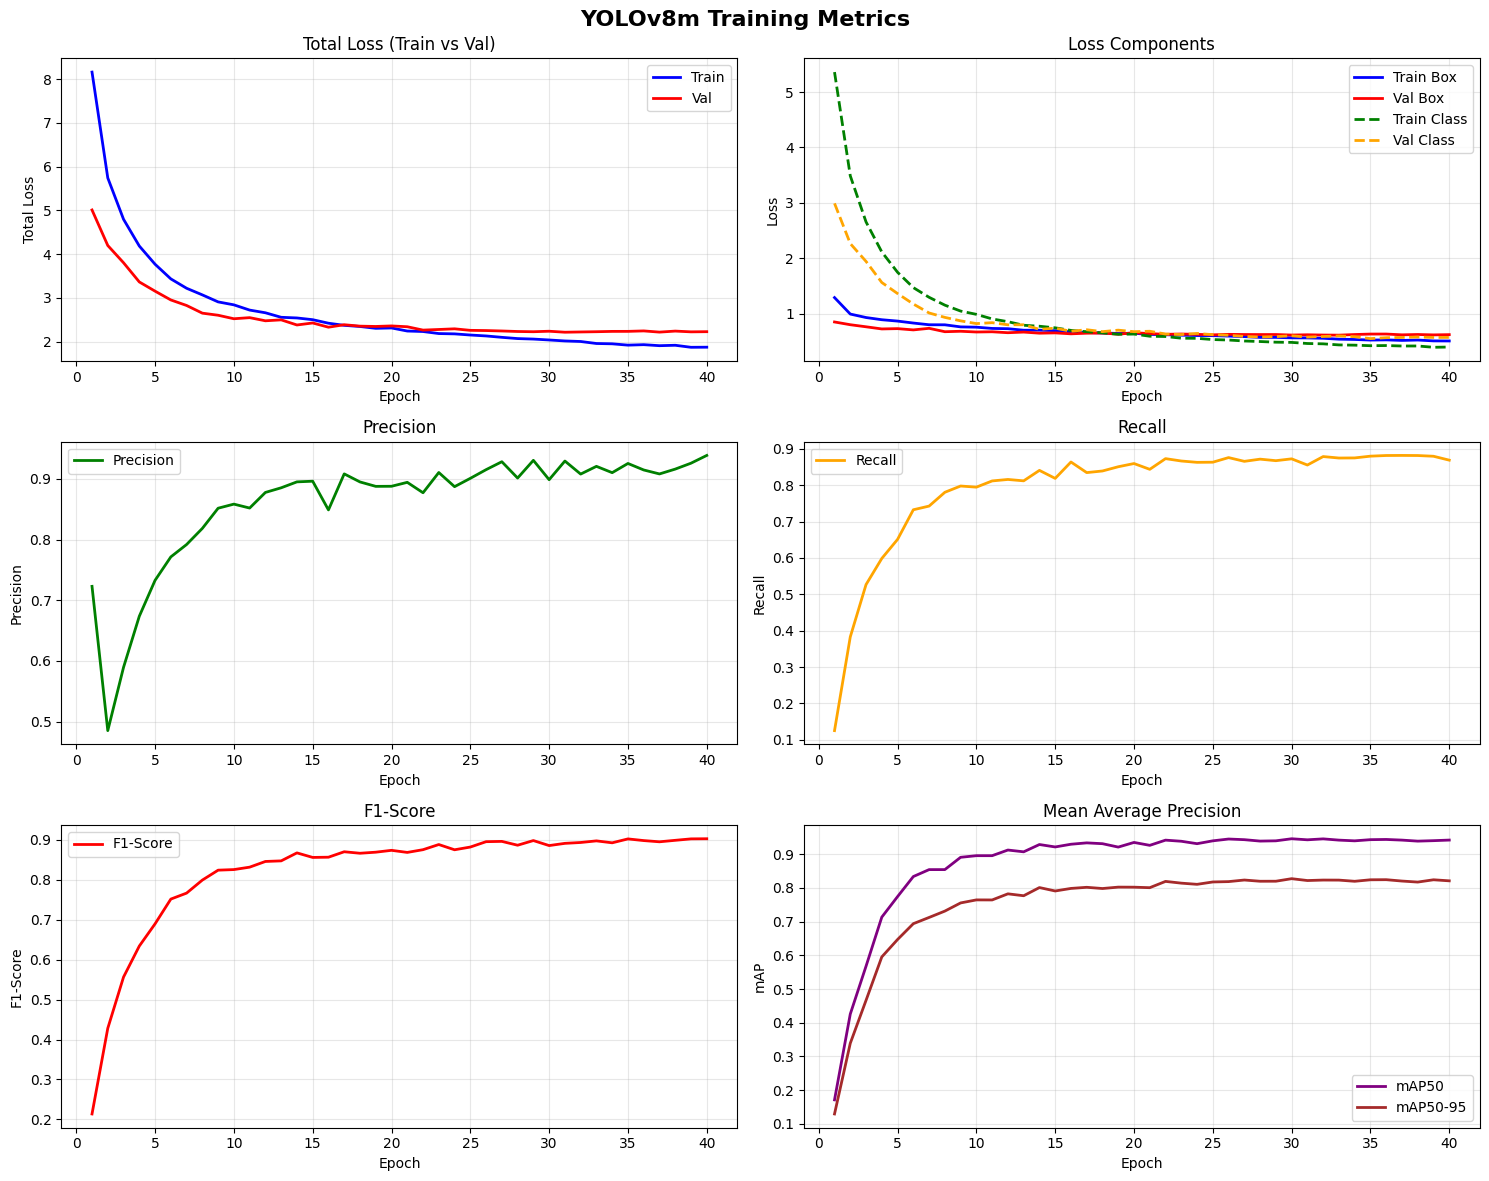

Metrics plot saved to: /content/yolov8_project/training_metrics.png


In [ ]:
print("Plotting YOLOv8m Metrics")

results_csv_v8 = yolov8_dir / 'train' / 'results.csv'
df_v8 = pd.read_csv(results_csv_v8)
df_v8.columns = df_v8.columns.str.strip()

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('YOLOv8m Training Metrics', fontsize=16, fontweight='bold')

# Total Loss (Train vs Val)
total_loss_train = df_v8['train/box_loss'] + df_v8['train/cls_loss'] + df_v8['train/dfl_loss']
total_loss_val = df_v8['val/box_loss'] + df_v8['val/cls_loss'] + df_v8['val/dfl_loss']
axes[0, 0].plot(df_v8['epoch'], total_loss_train, label='Train', linewidth=2, color='blue')
axes[0, 0].plot(df_v8['epoch'], total_loss_val, label='Val', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Total Loss (Train vs Val)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss Components (Box Loss & Class Loss)
axes[0, 1].plot(df_v8['epoch'], df_v8['train/box_loss'], label='Train Box', linewidth=2, linestyle='-', color='blue')
axes[0, 1].plot(df_v8['epoch'], df_v8['val/box_loss'], label='Val Box', linewidth=2, linestyle='-', color='red')
axes[0, 1].plot(df_v8['epoch'], df_v8['train/cls_loss'], label='Train Class', linewidth=2, linestyle='--', color='green')
axes[0, 1].plot(df_v8['epoch'], df_v8['val/cls_loss'], label='Val Class', linewidth=2, linestyle='--', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Loss Components')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(df_v8['epoch'], df_v8['metrics/precision(B)'], label='Precision', linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(df_v8['epoch'], df_v8['metrics/recall(B)'], label='Recall', linewidth=2, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# F1-Score
if 'metrics/f1(B)' in df_v8.columns:
    axes[2, 0].plot(df_v8['epoch'], df_v8['metrics/f1(B)'], label='F1-Score', linewidth=2, color='red')
else:
    precision = df_v8['metrics/precision(B)']
    recall = df_v8['metrics/recall(B)']
    f1 = 2 * (precision * recall) / (precision + recall)
    axes[2, 0].plot(df_v8['epoch'], f1, label='F1-Score', linewidth=2, color='red')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('F1-Score')
axes[2, 0].set_title('F1-Score')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# mAP
axes[2, 1].plot(df_v8['epoch'], df_v8['metrics/mAP50(B)'], label='mAP50', linewidth=2, color='purple')
axes[2, 1].plot(df_v8['epoch'], df_v8['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2, color='brown')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('mAP')
axes[2, 1].set_title('Mean Average Precision')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(yolov8_dir / 'training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Metrics plot saved to: {yolov8_dir / 'training_metrics.png'}")

###YOLOv11m

In [ ]:
rf = Roboflow(api_key="yR3ri8Ot8Ip9ZDNnTCvT")
project = rf.workspace("scholasticas").project("skripsii-5b")
version = project.version(3)
dataset_v11 = version.download("yolov11", location=str(yolov11_dir / 'dataset'))
print(f"YOLOv11 dataset downloaded to: {yolov11_dir / 'dataset'}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/yolov11_project/dataset in yolov11:: 100%|██████████| 10825/10825 [00:01<00:00, 10470.84it/s]

YOLOv11 dataset downloaded to: /content/yolov11_project/dataset


In [ ]:
print("Training YOLOv11m")
data_yaml_v11 = yolov11_dir / 'dataset' / 'data.yaml'
try:
    model_v11 = YOLO('yolo11m.pt')
except:
    try:
        model_v11 = YOLO('yolov11m.pt')
    except:
        print("Downloading YOLO11m model...")
        model_v11 = YOLO('yolo11m.pt')

results_v11 = model_v11.train(
    data=str(data_yaml_v11),
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.01,
    patience=10,
    mosaic=1,
    close_mosaic=0,
    save=True,
    project=str(yolov11_dir),
    name='train',
    exist_ok=True,
    verbose=True
)

print("YOLOv11m training completed!")
best_model_v11_path = yolov11_dir / 'train' / 'weights' / 'best.pt'
print(f"Best model saved at: {best_model_v11_path}")

Training YOLOv11m
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov11_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimize

In [ ]:
print("Validating YOLOv11m")
model_v11_best = YOLO(str(best_model_v11_path))
val_results_v11 = model_v11_best.val(
    data=str(data_yaml_v11),
    split='val',
    save_json=True,
    save_hybrid=True,
    project=str(yolov11_dir),
    name='validation',
    exist_ok=True
)

print("YOLOv11m validation completed!")

Validating YOLOv11m
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO11m summary (fused): 126 layers, 20,130,262 parameters, 0 gradients, 68.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 861.4±290.1 MB/s, size: 20.8 KB)
val: Scanning /content/yolov11_project/dataset/valid/labels.cache... 452 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 452/452 172.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 7.1it/s 4.1s
                   all        452        617      0.934      0.881      0.955      0.835
                  Adik          4          5       0.95        0.6      0.595      0.568
                   Apa          3          5      0.991          1      0.995      0.668
             Apa kabar          3          4          1      0.906      0.995      0.808
          

In [ ]:
print("Testing YOLOv11m")
test_results_v11 = model_v11_best.val(
    data=str(data_yaml_v11),
    split='test',
    save_json=True,
    save_hybrid=True,
    project=str(yolov11_dir),
    name='test',
    exist_ok=True
)

print("YOLOv11m testing completed!")

Testing YOLOv11m
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 850.5±278.4 MB/s, size: 22.2 KB)
val: Scanning /content/yolov11_project/dataset/test/labels... 223 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 1.5Kit/s 0.2s
val: New cache created: /content/yolov11_project/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 5.3it/s 2.6s
                   all        223        286       0.91      0.907      0.961      0.847
                  Adik          4          4      0.978          1      0.995      0.821
                   Apa          3          4      0.959          1      0.995      0.721
                 Bapak          2          2      0.926          1      0.995      0.895
               Bekerja          

In [ ]:
print("Evaluating YOLOv11m")
metrics_v11 = {
    'Precision': test_results_v11.box.p.mean(),
    'Recall': test_results_v11.box.r.mean(),
    'F1-Score': test_results_v11.box.f1.mean(),
    'mAP50': test_results_v11.box.map50,
    'mAP50-95': test_results_v11.box.map
}

print("\nYOLOv11m Test Metrics:")
for metric, value in metrics_v11.items():
    print(f"{metric}: {value:.4f}")

with open(yolov11_dir / 'test_metrics.json', 'w') as f:
    json.dump({k: float(v) for k, v in metrics_v11.items()}, f, indent=4)

Evaluating YOLOv11m

YOLOv11m Test Metrics:
Precision: 0.9098
Recall: 0.9072
F1-Score: 0.8906
mAP50: 0.9615
mAP50-95: 0.8472


Plotting YOLOv11m Metrics


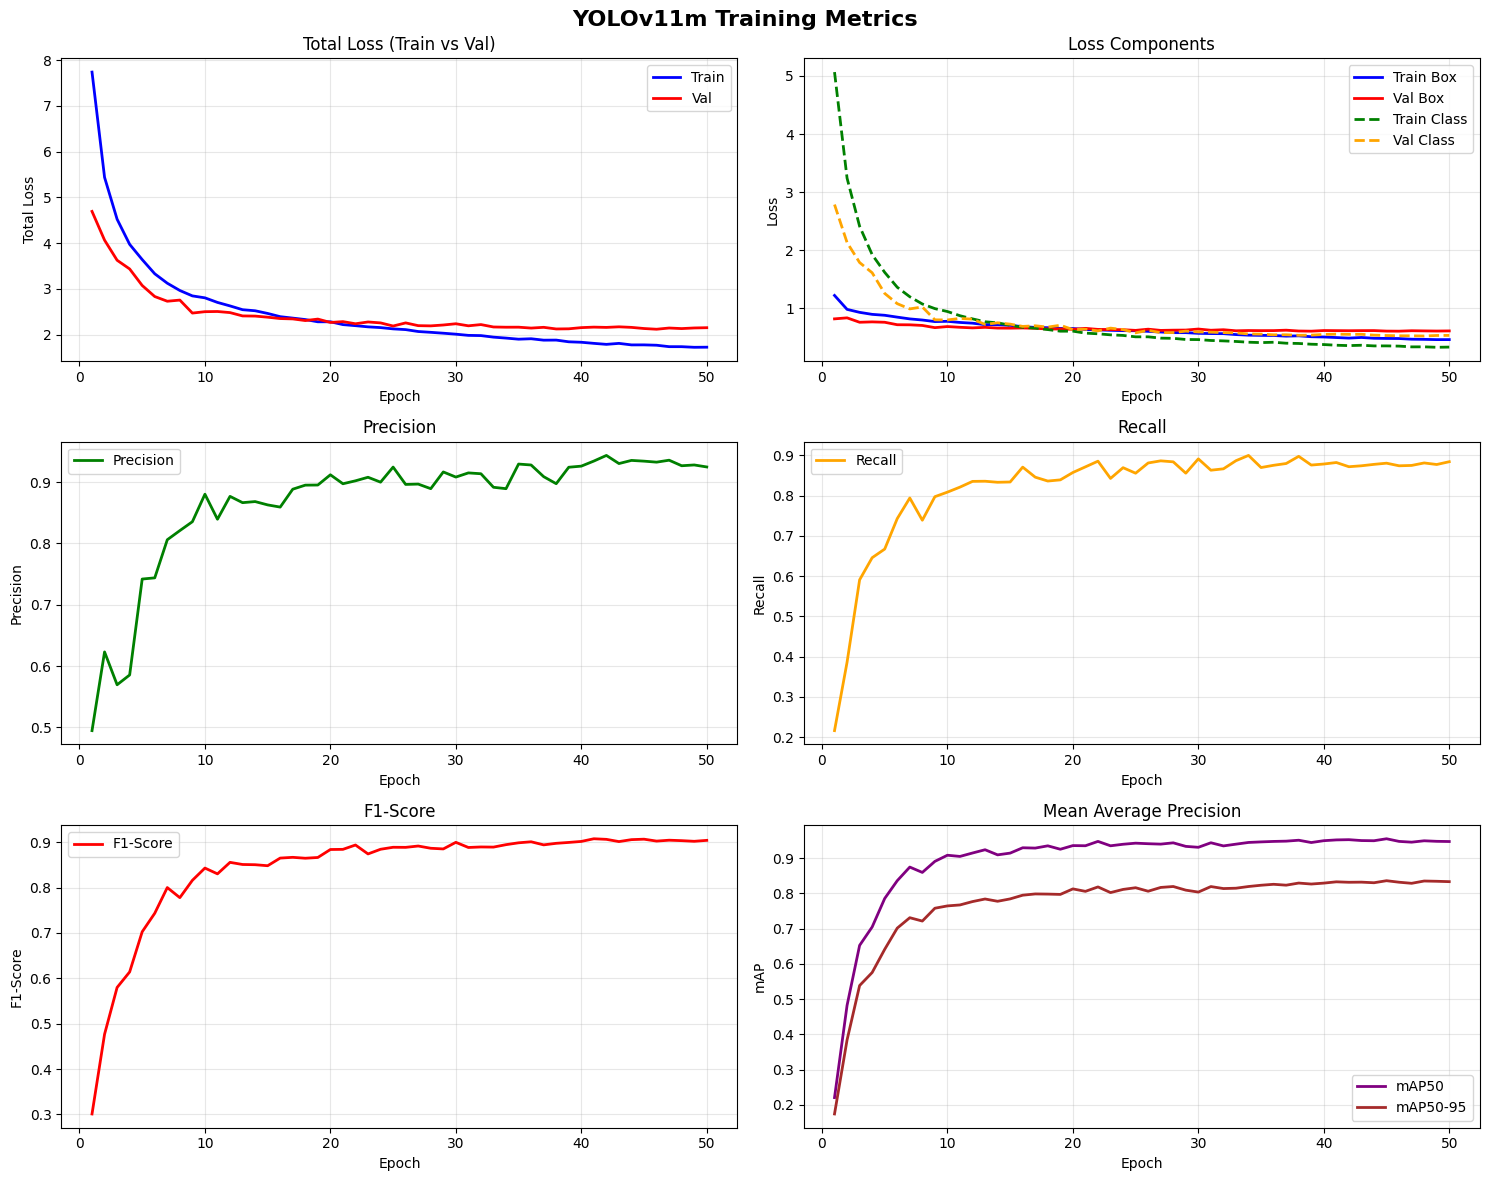

Metrics plot saved to: /content/yolov11_project/training_metrics.png


In [ ]:
print("Plotting YOLOv11m Metrics")
results_csv_v11 = yolov11_dir / 'train' / 'results.csv'
df_v11 = pd.read_csv(results_csv_v11)
df_v11.columns = df_v11.columns.str.strip()

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('YOLOv11m Training Metrics', fontsize=16, fontweight='bold')

# Total Loss (Train vs Val)
total_loss_train = df_v11['train/box_loss'] + df_v11['train/cls_loss'] + df_v11['train/dfl_loss']
total_loss_val = df_v11['val/box_loss'] + df_v11['val/cls_loss'] + df_v11['val/dfl_loss']
axes[0, 0].plot(df_v11['epoch'], total_loss_train, label='Train', linewidth=2, color='blue')
axes[0, 0].plot(df_v11['epoch'], total_loss_val, label='Val', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Total Loss (Train vs Val)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss Components (Box Loss & Class Loss)
axes[0, 1].plot(df_v11['epoch'], df_v11['train/box_loss'], label='Train Box', linewidth=2, linestyle='-', color='blue')
axes[0, 1].plot(df_v11['epoch'], df_v11['val/box_loss'], label='Val Box', linewidth=2, linestyle='-', color='red')
axes[0, 1].plot(df_v11['epoch'], df_v11['train/cls_loss'], label='Train Class', linewidth=2, linestyle='--', color='green')
axes[0, 1].plot(df_v11['epoch'], df_v11['val/cls_loss'], label='Val Class', linewidth=2, linestyle='--', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Loss Components')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(df_v11['epoch'], df_v11['metrics/precision(B)'], label='Precision', linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(df_v11['epoch'], df_v11['metrics/recall(B)'], label='Recall', linewidth=2, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# F1-Score
if 'metrics/f1(B)' in df_v11.columns:
    axes[2, 0].plot(df_v11['epoch'], df_v11['metrics/f1(B)'], label='F1-Score', linewidth=2, color='red')
else:
    precision = df_v11['metrics/precision(B)']
    recall = df_v11['metrics/recall(B)']
    f1 = 2 * (precision * recall) / (precision + recall)
    axes[2, 0].plot(df_v11['epoch'], f1, label='F1-Score', linewidth=2, color='red')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('F1-Score')
axes[2, 0].set_title('F1-Score')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# mAP
axes[2, 1].plot(df_v11['epoch'], df_v11['metrics/mAP50(B)'], label='mAP50', linewidth=2, color='purple')
axes[2, 1].plot(df_v11['epoch'], df_v11['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2, color='brown')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('mAP')
axes[2, 1].set_title('Mean Average Precision')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(yolov11_dir / 'training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Metrics plot saved to: {yolov11_dir / 'training_metrics.png'}")

In [ ]:
# CONFUSION MATRIX
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/hasil_evaluasi_perkelas.csv'
df = pd.read_csv(CSV_PATH)
df = df[df["Class"] != "all"]

for col in ["Instances", "P", "R"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["TP"] = (df["R"] * df["Instances"]).round().astype(int)
df["FN"] = (df["Instances"] - df["TP"]).round().astype(int)
df["FP"] = (df["TP"] * ((1 / df["P"]) - 1)).fillna(0).round().astype(int)
total_tp = df["TP"].sum()
total_fp = df["FP"].sum()
total_fn = df["FN"].sum()

print("=" * 40)
print("CONFUSION MATRIX SUMMARY")
print("=" * 40)
print(f"Total TP : {total_tp}")
print(f"Total FP : {total_fp}")
print(f"Total FN : {total_fn}")

conf_matrix = np.array([
    [total_tp, total_fn],
    [total_fp, np.nan]
])
labels = ["Positive", "Negative"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    mask=np.isnan(conf_matrix),
    cbar=False
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

Model Comparison
   Model  Precision   Recall  F1-Score    mAP50  mAP50-95
 YOLOv8m   0.903491 0.883973  0.866743 0.952622  0.832558
YOLOv11m   0.909789 0.907171  0.890581 0.961472  0.847230


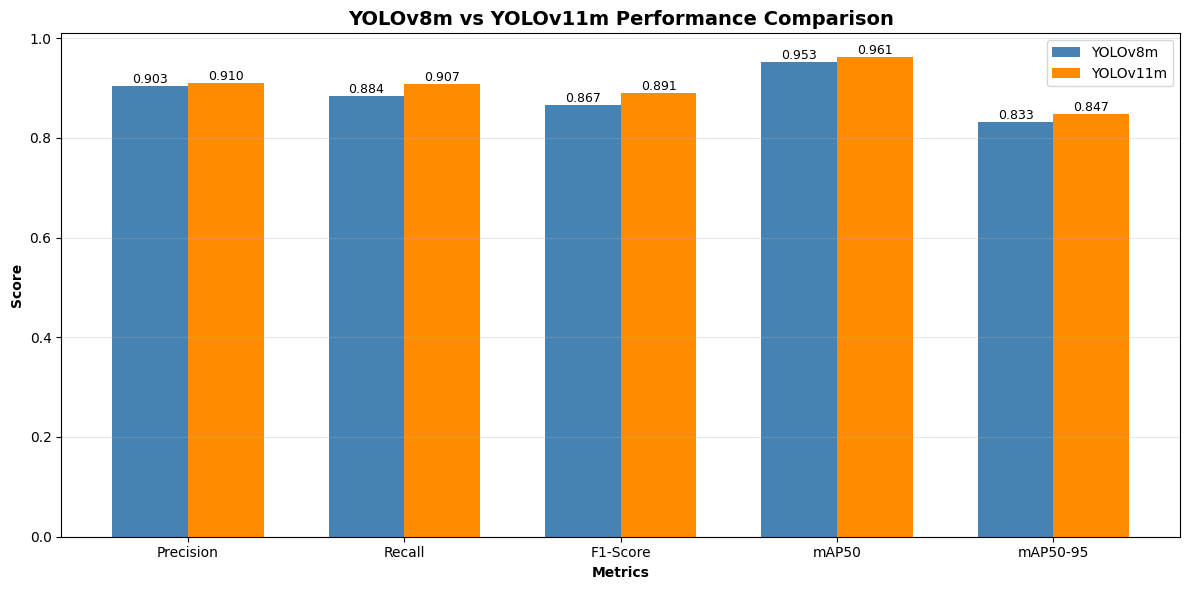


Comparison plot saved to: /content/model_comparison.png


In [ ]:
print("Model Comparison")

comparison_df = pd.DataFrame({
    'Model': ['YOLOv8m', 'YOLOv11m'],
    'Precision': [metrics_v8['Precision'], metrics_v11['Precision']],
    'Recall': [metrics_v8['Recall'], metrics_v11['Recall']],
    'F1-Score': [metrics_v8['F1-Score'], metrics_v11['F1-Score']],
    'mAP50': [metrics_v8['mAP50'], metrics_v11['mAP50']],
    'mAP50-95': [metrics_v8['mAP50-95'], metrics_v11['mAP50-95']]
})

print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df.columns) - 1)
width = 0.35

metrics_list = ['Precision', 'Recall', 'F1-Score', 'mAP50', 'mAP50-95']
v8_values = [metrics_v8[m] for m in metrics_list]
v11_values = [metrics_v11[m] for m in metrics_list]

bars1 = ax.bar(x - width/2, v8_values, width, label='YOLOv8m', color='steelblue')
bars2 = ax.bar(x + width/2, v11_values, width, label='YOLOv11m', color='darkorange')

ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('YOLOv8m vs YOLOv11m Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(base_dir / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComparison plot saved to: {base_dir / 'model_comparison.png'}")